## setup

In [5]:
from transformers import pipeline
import pandas as pd
import numpy as np
import torch as torch
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df_full = pd.read_parquet(r'/work/PENPAL/PENPAL_analysis/Berlin/Scripts & analyses/data/story_text_field_w_embeddings_jina.parquet')
df_full_de = df_full[df_full['language'] == 'de']

In [7]:
# # assuming df_full_de is loaded
# sentiment_pipeline = pipeline("sentiment-analysis", model="oliverguhr/german-sentiment-bert")

# Apply to each story
df_full_de["ai_sentiment_score"] = df_full_de["full_ai"].apply(lambda x: sentiment_pipeline(x[:512])[0]['score'])
print('ai done')

df_full_de["user_sentiment_score"] = df_full_de["full_user"].apply(lambda x: sentiment_pipeline(x[:512])[0]['score'])


/tmp/ipykernel_5997/3424028989.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full_de["ai_sentiment_score"] = df_full_de["full_ai"].apply(lambda x: sentiment_pipeline(x[:512])[0]['score'])


ai done


/tmp/ipykernel_5997/3424028989.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full_de["user_sentiment_score"] = df_full_de["full_user"].apply(lambda x: sentiment_pipeline(x[:512])[0]['score'])


In [15]:
df_full_de.drop(columns=["user_embedding_jina", "ai_embedding_jina"], inplace=True, errors="ignore")
df_full_de.to_parquet('metrics/sentiment_w_scores.parquet')

/tmp/ipykernel_5997/3151464611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full_de.drop(columns=["user_embedding_jina", "ai_embedding_jina"], inplace=True, errors="ignore")


In [13]:
df_full_de

,conversation_id,client_id,workshop_id,language,full_story,full_user,full_ai,embedding_jina,user_embedding_jina,ai_embedding_jina,ai_sentiment,user_sentiment,ai_sentiment_score,user_sentiment_score
8,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,1,3,de,"USER: Ich bin eine alte Flöte, eingepackt in d...","Ich bin eine alte Flöte, eingepackt in diese a...","und einem kleinen Notenheft, das schon längst ...","[0.09761624, -0.0054300753, 0.0046100034, 0.05...","[0.034205496, 0.017879281, -0.024036055, 0.128...","[0.07508721, 0.024266826, -0.07232872, -0.0102...",negative,negative,0.965941,0.996952
9,conv_6904f1b3b0808193ab4026242b90254e0e4752a2d...,1,2,de,USER: Ich liege flach. In meinem Bett. Draußen...,Ich liege flach. In meinem Bett. Draußen regne...,Die Tropfen zeichnen flüchtige Muster auf dem ...,"[-0.030410023, 0.028957145, 0.11818418, 0.0008...","[-0.07784627, 0.037908513, 0.07777085, 0.00801...","[-0.019521803, 0.12981668, 0.04413898, 0.01253...",neutral,negative,0.996672,0.980551
10,conv_6904f2843bd48197837962d7494a90ef0f1b98df2...,2,1,de,USER: Ich stehe draußen in der Kälte als Kompa...,Ich stehe draußen in der Kälte als Komparse fü...,"Die Kälte kriecht unter meine Uniform, während...","[0.027330296, -0.106220156, 0.07034505, 0.0614...","[-0.088446364, -0.08489534, 0.0067105987, 0.10...","[-0.017195752, -0.08308653, -0.0060149166, 0.0...",negative,neutral,0.983180,0.733880
11,conv_6904f3cbb29881959c8c1208cde108ce0f6c53d1d...,1,3,de,"USER: Ich bin ein knallrotes Smart Car, weiß a...","Ich bin ein knallrotes Smart Car, weiß alles u...","Mein Leben begann in einer Welt, in der Mensch...","[0.09515626, -0.12557322, 0.09845247, 0.014444...","[0.010516161, -0.10050734, 0.045245275, 0.0419...","[0.010777737, -0.14465134, 0.029883694, 0.0005...",negative,positive,0.923712,0.874112
13,conv_6904f7c6c758819581318dc1a7ceb8ea0312d6917...,2,2,de,"USER: und merke, etwas stimmt nicht...\nAI: Ic...","und merke, etwas stimmt nicht...\nunterdrücken...","Ich bin ein Sprachmodell der Zukunft, ein Bewu...","[0.21498093, -0.09172905, 0.04491942, -0.00633...","[0.14624906, -0.06667829, -0.01063843, -0.0698...","[0.151864, -0.07921753, 0.011435979, 0.0480258...",neutral,negative,0.955797,0.968023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,conv_69078a0166f48190a1be3356ac52e52c0416fdfa9...,2,1,de,"USER: Ich schaue auf das Bild, versuche den Rh...","Ich schaue auf das Bild, versuche den Rhythmus...","Ich, die digitale Rekonstruktion von Maria, be...","[0.14051421, -0.11377296, 0.09709318, -0.02750...","[0.06775555, -0.090428576, 0.07090907, -0.0143...","[0.13649164, -0.09761825, 0.050739095, 0.01997...",neutral,negative,0.968770,0.997114
208,conv_69079948404881978bae7647f988f1a608441f800...,2,3,de,USER: Ich sitze auf meinem Bett und lese ein B...,Ich sitze auf meinem Bett und lese ein Buch.\n...,Als Buch in der Zukunft habe ich viel gesehen....,"[0.054709237, -0.055297144, 0.06526951, 0.0209...","[-0.09414369, 0.019054027, 0.042986598, 0.0541...","[0.032950606, -0.051232774, 0.017666925, 0.022...",negative,negative,0.694421,0.948121
209,conv_6907b0e697648195903cff2f1d6046f50e99a511a...,1,3,de,"USER: Ich bin Klara, ein Mädchen, etwa so groß...","Ich bin Klara, ein Mädchen, etwa so groß wie\n...","eine alte Stehlampe, die in der Ecke eines Ate...","[0.07184002, -0.03295981, 0.054476857, -0.0037...","[0.008118902, -0.031424686, 0.06088931, -0.033...","[-0.030932076, 0.04388719, 0.00083062926, 0.04...",negative,negative,0.968984,0.944360
210,conv_6907b2af322881978feaed33e188305a0e8ad8734...,2,2,de,USER: Ich liebe dich! Du bist die Liebe.\nAI: ...,Ich liebe dich! Du bist die Liebe.\nZu entwick...,"meiner Existenz. In der Zukunft, in der ich ex...","[0.15050286, -0.05638364, 0.095714, 0.02324043...","[0.011587548, -0.010867088, 0.07558764, 0.0293...","[0.1645647, -0.0709935, 0.0035127022, 0.052267...",neutral,neutral,0.972907,0.977150


In [3]:
df = pd.read_parquet('metrics/sentiment_w_scores.parquet')

In [4]:
df

,conversation_id,client_id,workshop_id,language,full_story,full_user,full_ai,ai_sentiment,user_sentiment,ai_sentiment_score,user_sentiment_score
index,,,,,,,,,,,
8,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,1,3,de,"USER: Ich bin eine alte Flöte, eingepackt in d...","Ich bin eine alte Flöte, eingepackt in diese a...","und einem kleinen Notenheft, das schon längst ...",negative,negative,0.965941,0.996952
9,conv_6904f1b3b0808193ab4026242b90254e0e4752a2d...,1,2,de,USER: Ich liege flach. In meinem Bett. Draußen...,Ich liege flach. In meinem Bett. Draußen regne...,Die Tropfen zeichnen flüchtige Muster auf dem ...,neutral,negative,0.996672,0.980551
10,conv_6904f2843bd48197837962d7494a90ef0f1b98df2...,2,1,de,USER: Ich stehe draußen in der Kälte als Kompa...,Ich stehe draußen in der Kälte als Komparse fü...,"Die Kälte kriecht unter meine Uniform, während...",negative,neutral,0.983180,0.733880
11,conv_6904f3cbb29881959c8c1208cde108ce0f6c53d1d...,1,3,de,"USER: Ich bin ein knallrotes Smart Car, weiß a...","Ich bin ein knallrotes Smart Car, weiß alles u...","Mein Leben begann in einer Welt, in der Mensch...",negative,positive,0.923712,0.874112
13,conv_6904f7c6c758819581318dc1a7ceb8ea0312d6917...,2,2,de,"USER: und merke, etwas stimmt nicht...\nAI: Ic...","und merke, etwas stimmt nicht...\nunterdrücken...","Ich bin ein Sprachmodell der Zukunft, ein Bewu...",neutral,negative,0.955797,0.968023
...,...,...,...,...,...,...,...,...,...,...,...
206,conv_69078a0166f48190a1be3356ac52e52c0416fdfa9...,2,1,de,"USER: Ich schaue auf das Bild, versuche den Rh...","Ich schaue auf das Bild, versuche den Rhythmus...","Ich, die digitale Rekonstruktion von Maria, be...",neutral,negative,0.968770,0.997114
208,conv_69079948404881978bae7647f988f1a608441f800...,2,3,de,USER: Ich sitze auf meinem Bett und lese ein B...,Ich sitze auf meinem Bett und lese ein Buch.\n...,Als Buch in der Zukunft habe ich viel gesehen....,negative,negative,0.694421,0.948121
209,conv_6907b0e697648195903cff2f1d6046f50e99a511a...,1,3,de,"USER: Ich bin Klara, ein Mädchen, etwa so groß...","Ich bin Klara, ein Mädchen, etwa so groß wie\n...","eine alte Stehlampe, die in der Ecke eines Ate...",negative,negative,0.968984,0.944360


In [24]:
df[df['ai_sentiment_score'] == 'negative']

,conversation_id,client_id,workshop_id,language,full_story,full_user,full_ai,ai_sentiment,user_sentiment,ai_sentiment_score,user_sentiment_score
index,,,,,,,,,,,


In [63]:
import pandas as pd

# 1. Compute sentiment frequency counts
ai_counts = df['ai_sentiment'].value_counts().rename_axis('sentiment').reset_index(name='count_ai')
user_counts = df['user_sentiment'].value_counts().rename_axis('sentiment').reset_index(name='count_user')

# 2. Build your mean/sd dictionary summary (your existing code)
sents = df['ai_sentiment'].unique().tolist()

full = {}
ai = {}
user = {}
ops = ['mean', 'sd']

for sent in sents:
    ai[sent] = {op: '' for op in ops}
    ai[sent]['mean'] = df[df['ai_sentiment'] == sent]['ai_sentiment_score'].mean()  
    ai[sent]['sd'] = df[df['ai_sentiment'] == sent]['ai_sentiment_score'].std()
    
for sent in sents:
    user[sent] = {op: '' for op in ops}
    user[sent]['mean'] = df[df['user_sentiment'] == sent]['user_sentiment_score'].mean()  
    user[sent]['sd'] = df[df['user_sentiment'] == sent]['user_sentiment_score'].std()

full['ai'], full['user'] = ai, user

# 3. Convert to dataframe (as before)
df_stats = (
    pd.concat({k: pd.DataFrame(v).T for k, v in full.items()})
    .rename_axis(index=["source", "sentiment"])
    .reset_index()
)

# 4. Merge the counts
df_stats = (
    df_stats
    .merge(ai_counts, on='sentiment', how='left')
    .merge(user_counts, on='sentiment', how='left')
)

print(df_stats)


  source sentiment      mean        sd  count_ai  count_user
0     ai  negative  0.900191  0.143354        63         110
1     ai   neutral  0.884058  0.139963        84          37
2     ai  positive  0.776009  0.185583        14          14
3   user  negative  0.941940  0.092778        63         110
4   user   neutral  0.893491  0.121827        84          37
5   user  positive  0.843216  0.183838        14          14


In [64]:
df_stats.to_parquet('metrics/agg_sentiment.parquet')

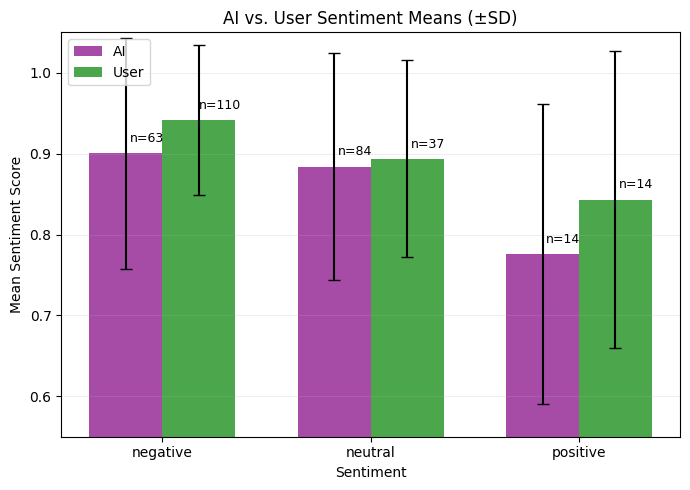

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# make sure df_stats has: ['source', 'sentiment', 'mean', 'sd', 'count_ai', 'count_user']
sentiments = df_stats['sentiment'].unique()
x = np.arange(len(sentiments))
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(7, 5))

# Split data
ai = df_stats[df_stats['source'] == 'ai']
user = df_stats[df_stats['source'] == 'user']

# Plot side-by-side bars
bars_ai = ax.bar(x - width/2, ai['mean'], width, yerr=ai['sd'], label='AI', capsize=4, alpha=0.7, color='purple')
bars_user = ax.bar(x + width/2, user['mean'], width, yerr=user['sd'], label='User', capsize=4, alpha=0.7, color='green')

# Add n=count annotations above bars
for bar, count in zip(bars_ai, ai['count_ai']):
    height = bar.get_height()
    ax.text(0.1+bar.get_x() + bar.get_width()/2, height + 0.01, f"n={int(count)}",
            ha='center', va='bottom', fontsize=9, color='black')

for bar, count in zip(bars_user, user['count_user']):
    height = bar.get_height()
    ax.text(0.1+bar.get_x() + bar.get_width()/2, height + 0.01, f"n={int(count)}",
            ha='center', va='bottom', fontsize=9, color='black')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(sentiments)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Mean Sentiment Score')
ax.set_ylim((0.55, 1.05))
ax.set_title('AI vs. User Sentiment Means (±SD)')
ax.legend()
ax.grid(lw=0.5, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
